In [1]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Sequence, Annotated, NotRequired, cast
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage, AIMessageChunk
from operator import add as add_messages
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from pydantic import SecretStr
from langchain_core.runnables import RunnableConfig

load_dotenv()

OPENROUTER_BASE_URL = os.getenv("OPENROUTER_BASE_URL")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("There isn't any api key!")

llm = ChatOpenAI(
    model="qwen/qwen3-coder-plus",
    api_key=SecretStr(OPENAI_API_KEY),
    base_url=OPENROUTER_BASE_URL,
    temperature=0
)

In [2]:
llm.invoke("Hello")

AIMessage(content='Hello! ٩(◕‿◕｡)۶ How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 9, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 7.085e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.000109, 'upstream_inference_prompt_cost': 9e-06, 'upstream_inference_completions_cost': 0.0001}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-coder-plus', 'system_fingerprint': None, 'id': 'gen-1773309381-DMoOcuFJvsBZa1rrOlPi', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce179-cc74-78d3-8b04-04e75c1b1443-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 20, 'total_token

In [34]:
pdf_path = "../data/Stock_Market_Performance_2024.pdf"

In [35]:
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")

In [36]:
pdf_loader = PyPDFLoader(pdf_path) 

In [37]:
try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF has been loaded and has 9 pages


In [38]:
text_spliter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap = 200
)

In [39]:
pages_split = text_spliter.split_documents(pages)

In [40]:
persist_derictory = "/data/T7/linux/MyFirstAgent/databases"
collection_name = "stock_market"

In [41]:
if not os.path.exists(persist_derictory):
    os.makedirs(persist_derictory)
    print(f"Directory was made with path {persist_derictory}")
else:
    print(f"Folder '{persist_derictory}' already exist")

Folder '/data/T7/linux/MyFirstAgent/databases' already exist


In [42]:
try:
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_derictory,
        collection_name=collection_name
    )
    print(f"Created ChromaDB vector store")

except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise

Created ChromaDB vector store


In [43]:
retriever = vectorstore.as_retriever(
    search_type = "similarity",
    search_kwards = {"k": 5}
)

In [44]:
@tool
def retriever_tool(query: str) -> str:
    """
    Search the 'Stock Market Performance 2024' document to retrieve relevant information about stock market performance.
    """
    docs = retriever.invoke(query)
    
    if not docs:
        return "I found no relevant information in the Stock Market Performance 2024 document"
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")
    
    return "\n\n".join(results)



In [45]:
tools = [retriever_tool]
llm_with_tool = llm.bind_tools(
    tools=tools
    )

In [46]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [47]:
def should_continue(state: AgentState) -> bool:
    """Check whether the last AI message contains tool calls."""
    last_message = state["messages"][-1]
    return bool(getattr(last_message, "tool_calls", None))

In [48]:
system_prompt = """
You are an intelligent AI assistant who answers questions about Stock Market Performance in 2024 based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the stock market performance data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of the documents you use in your answers.
"""

In [49]:
tools_dict = {our_tool.name: our_tool for our_tool in tools}

In [50]:
def call_llm(state: AgentState) -> dict:
    """Function to call the LLM with the current state."""
    messages = list(state["messages"])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm_with_tool.invoke(messages)
    return {"messages": [message]}

In [51]:
def take_action(state: AgentState) -> dict:
    tool_calls = cast(AIMessage, state["messages"][-1]).tool_calls
    results = []

    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")
        
        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")
            

        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

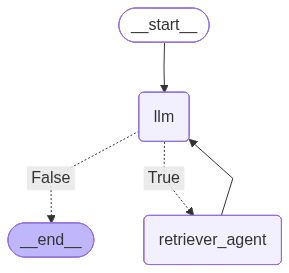

In [52]:
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

rag_agent = graph.compile()
rag_agent

In [53]:
def running_agent():
    print("\n=== RAG AGENT===")
    
    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit', 'quit']:
            break
            
        messages = [HumanMessage(content=user_input)] # converts back to a HumanMessage type

        result = rag_agent.invoke({"messages": messages})
        
        print("\n=== ANSWER ===")
        print(result['messages'][-1].content)


running_agent()


=== RAG AGENT===

=== ANSWER ===
I can provide information about Amazon Web Services (AWS) up to October 2023. AWS is a subsidiary of Amazon providing on-demand cloud computing platforms and APIs to individuals, companies, and governments, on a metered pay-as-you-go basis. It is one of the most comprehensive and widely adopted cloud platforms, offering over 200 fully featured services from data centers globally. AWS services include computing power, storage options, and networking, among others, and are used by millions of customers, including startups, enterprises, and government agencies, to lower costs, become more agile, and innovate faster.

If you are looking for specific information about AWS's performance or developments in 2024, please let me know, and I can search for relevant information in the "Stock Market Performance 2024" document.

=== ANSWER ===
Could you please specify what information you would like me to look for regarding the Stock Market Performance in 2024?

===